Processed data is stored in pkl file<br>
Load data and fit with PyMC<br>
Pt100 KOH CO oxidation<br>

**Models:**<br> 

ER:<br> 
1. CO + * -> CO*<br> 
2. CO* + OH- -> COOH* + e-<br> 
3. COOH* + OH- -> CO2 + H2O + * + e-<br>
4. OH- + * -> OH* + e-<br>

LH: <br>
1. CO + * -> CO*<br>
2. CO* + OH* -> COOH* + *<br> 
3. COOH* + OH- -> CO2 + H2O + * + e-<br>
4. OH- + * -> OH* + e-<br>

Updates: 
1. 

# Initialization - Rate only

In [2]:
import numpy as np
import pymc as pm
import arviz as az
import pandas as pd
import xarray as xr
import pickle 
import nutpie
import matplotlib.pyplot as plt
import pytensor.tensor as pt
import itertools

plt.rcParams['figure.dpi'] = 60
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)

# Experimental conditions and constants 
C_KOH_list = np.array([0.1, 0.25, 0.5, 1]) # in M 
P_CO_list = 0.01*np.array([0.1, 1, 10, 100]) # in atm
conditions = list(itertools.product(C_KOH_list, P_CO_list))
R, T, F = 8.3145, 298.15, 96485
kb_eV, h, kb_J = 8.617e-5, 6.626e-34, 1.3806e-23  # eV/K, J.s, J/K 

# Load and parse data
with open('Pt100_KOH.pkl', 'rb') as f:
    experiments_interp = pickle.load(f)
E_obs = experiments_interp[(0.1, 0.1)]['E'] # V vs SHE - random conditions

alpha_obs = np.zeros((len(C_KOH_list), len(P_CO_list), len(E_obs)))
for i, C_KOH in enumerate(C_KOH_list):
    for j, P_CO in enumerate(P_CO_list):
        alpha_obs[i, j, :] = experiments_interp[(C_KOH, P_CO)]['alpha']

delta_OH_obs = np.zeros((len(P_CO_list), len(E_obs)))
for j, P_CO in enumerate(P_CO_list):
    delta_OH_obs[j, :] = experiments_interp[(0.1, P_CO)]['delta_OH'] # Random C_KOH

delta_CO_obs = np.zeros((len(C_KOH_list), len(P_CO_list)-1, len(E_obs)))
for i, C_KOH in enumerate(C_KOH_list):
    for j, P_CO in enumerate(P_CO_list[:-1]): 
        delta_CO_obs[i, j, :] = experiments_interp[(C_KOH, P_CO)]['delta_CO']

rate_obs = np.zeros((len(C_KOH_list), len(P_CO_list), len(E_obs)))
for i, C_KOH in enumerate(C_KOH_list):
    for j, P_CO in enumerate(P_CO_list):
        rate_obs[i, j, :] = np.log(experiments_interp[(C_KOH, P_CO)]['rate'])

# Constructing variables to make it more feasible for models
# Variables reshaped for broadcasting
dE = E_obs[1] - E_obs[0]
d_ln_P_CO = np.diff(np.log(P_CO_list))[None, :, None]

# Need this because np.polyfit doesn't work with pymc variables - used for delta_OH
ln_C = np.log(C_KOH_list)
ln_C_mean = np.mean(ln_C)
S_xx = np.sum((ln_C - ln_C_mean)**2)
w_C = (ln_C - ln_C_mean) / S_xx
w_C_in = w_C[:, None, None]

C_KOH_in = C_KOH_list[:, None, None] # Shape (N, 1, 1)
P_CO_in = P_CO_list[None, :, None] # Shape (1, N, 1)
E_in = E_obs[None, None, :] # Shape (1, 1, N)

def calc_observables(log_rate): 
    '''
    Converts a raw rate tensor (C_KOH, P_CO, E) into kinetic observables (alpha, delta_OH, delta_CO).
    Returns PyTensor variables ready for the model.
    '''
    # Alpha with central difference (forward/backward difference at edges - no points lost)
    d_log_rate_dE = pt.zeros_like(log_rate)

    d_log_rate_center_dE = (log_rate[:, :, 2:] - log_rate[:, :, :-2]) / (2*dE)
    d_log_rate_dE = pt.set_subtensor(d_log_rate_dE[:, :, 1:-1], d_log_rate_center_dE)

    d_log_rate_start_dE = (log_rate[:, :, 1] - log_rate[:, :, 0]) / dE
    d_log_rate_dE = pt.set_subtensor(d_log_rate_dE[:, :, 0], d_log_rate_start_dE)
    
    d_log_rate_end_dE = (log_rate[:, :, -1] - log_rate[:, :, -2]) / dE
    d_log_rate_dE = pt.set_subtensor(d_log_rate_dE[:, :, -1], d_log_rate_end_dE)

    mu_alpha = (R*T/F) * d_log_rate_dE

    # Delta OH with linear regression: weights set up earlier
    mu_delta_OH = pm.math.sum(w_C_in * log_rate, axis=0)

    # Delta CO with finite difference, losing a P_CO point
    d_log_rate_P = log_rate[:, 1:, :] - log_rate[:, :-1, :]
    mu_delta_CO = d_log_rate_P / d_ln_P_CO

    return mu_alpha, mu_delta_OH, mu_delta_CO

def get_combined_loo(idata):
    """
    Merges multiple log-likelihood variables into a single array 
    and calculates the global LOO score, preserving the posterior for Reff.
    """
    ll_list = []
    
    # Loop through each observed variable
    for var_name in idata.log_likelihood.data_vars:
        da = idata.log_likelihood[var_name]

        # Identify experimental (controlled) dimensions
        obs_dims = [d for d in da.dims if d not in ('chain', 'draw')]

        # Flatten the experimental dims into a single 'obs' dimension
        if obs_dims: da_flat = da.stack(observations=obs_dims)
        else: da_flat = da.expand_dims(observations=1) # Handle scalars if any
            
        # Drop the coordinate labels (MultiIndex) so we can concatenate cleanly
        da_flat = da_flat.reset_index('observations', drop=True)
        ll_list.append(da_flat)
        
    # Concatenate all variables along the 'observations' dimension and give distinct indices
    combined_ll = xr.concat(ll_list, dim='observations')
    combined_ll = combined_ll.assign_coords(observations=range(combined_ll.sizes['observations']))
    
    # Create a new InferenceData object that has the new Likelihood AND the original Posterior
    new_idata = az.InferenceData(
        posterior=idata.posterior,  # Required for N_eff / Reff calculations
        log_likelihood=combined_ll.to_dataset(name='total_model')
    )
    
    return az.loo(new_idata, var_name='total_model', pointwise=True)

def calculate_flattened_r2(ppc, var_name):
    # 1. Get the real data and model predictions
    y_true = ppc.observed_data[var_name].values
    y_pred = ppc.posterior_predictive[var_name].values
    
    # y_true shape: (N_Conc, N_Pres, N_Volt) -> e.g., (1, 5, 20)
    # y_pred shape: (Chains, Draws, N_Conc, N_Pres, N_Volt)
    
    # 2. Flatten the dimensions so ArviZ sees a simple list of points
    # New y_true: (100,)
    y_true_flat = y_true.flatten()
    
    # New y_pred: (Chains, Draws, 100)
    # We keep the first two dims (Chains, Draws) and flatten the rest
    chains, draws = y_pred.shape[:2]
    y_pred_flat = y_pred.reshape(chains * draws, -1)
    
    # 3. Calculate R2
    r2 = az.r2_score(y_true_flat, y_pred_flat)
    return r2['r2']

def plot_posteriors(trace, model): 
    
    all_vars = list(trace.posterior.data_vars)
    var_names = [v for v in all_vars if not v.endswith("__")]
    error_keywords = ['omega', 'eta', 'gamma', 'sigma']
    error_vars = [v for v in var_names if v.startswith('sigma_') or v in error_keywords]
    kinetic_vars = [v for v in var_names if v not in error_vars and not v.startswith('theta')]
    print(f"Kinetic Parameters found: {kinetic_vars}")
    print(f"Error Parameters found: {error_vars}")

    summary = az.summary(trace, var_names=kinetic_vars + error_vars)
    print(summary)

    if kinetic_vars:
        az.plot_posterior(trace, var_names=kinetic_vars, 
                          hdi_prob=0.95, round_to=3, figsize=(14, 5))
        plt.suptitle("Kinetic Parameters (Physics)", y=1.05, fontsize=16, fontweight='bold')
        plt.show()

    if error_vars:
        az.plot_posterior(trace, var_names=error_vars, 
                            hdi_prob=0.95, round_to=3, figsize=(11, 3.5), color='grey')
        plt.suptitle("Error Model Parameters (Noise)", y=1.05, fontsize=16, fontweight='bold')
        plt.show()

    if len(kinetic_vars) > 1:
        az.plot_pair(trace, var_names=kinetic_vars + error_vars, 
                     kind='kde', divergences=True, figsize=(10, 9))
        plt.suptitle("Parameter Correlations", y=1.02, fontsize=16, fontweight='bold')
        plt.show()

    with model:
        ppc = pm.sample_posterior_predictive(trace, progressbar=False)

    for var_name in ppc.observed_data.data_vars:
        r2 = calculate_flattened_r2(ppc, var_name)
        print(f"{var_name}: {r2:.3f}")
        
    return ppc

def plot_model_fits(ppc):
    
    colors = plt.cm.tab10.colors[:len(P_CO_list)]
    '''
    # --- 1. Transfer Coefficients (Alpha) - 4x4 Grid ---
    # Rows = P_CO, Columns = C_KOH

    fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(16, 14), sharex=True, sharey=True)
    fig.suptitle('Transfer Coefficients (Model vs Exp)', fontsize=20, fontweight='bold', y=0.98)

    for i, C_KOH in enumerate(C_KOH_list):
        for j, P_CO in enumerate(P_CO_list):
            ax = axes[j, i]
            
            # 1. Experimental Data
            E_exp = experiments_interp[(C_KOH, P_CO)]['E']
            alpha_exp = experiments_interp[(C_KOH, P_CO)]['alpha']
            
            # 2. Model Prediction
            model_data = ppc.posterior_predictive['alpha'][:, :, i, j, :]
            model_mean = model_data.mean(dim=("chain", "draw"))
            
            # Calculate BOTH intervals
            hdi_95 = az.hdi(model_data, hdi_prob=0.95)[model_data.name]
            hdi_90 = az.hdi(model_data, hdi_prob=0.90)[model_data.name]
            
            # PLOT
            # 95% Interval (Wider, Fainter)
            ax.fill_between(E_exp, hdi_95[:, 0].values, hdi_95[:, 1].values, 
                            color=colors[j], alpha=0.15, linewidth=0, label='95% HDI')
            
            # 90% Interval (Narrower, Darker)
            ax.fill_between(E_exp, hdi_90[:, 0].values, hdi_90[:, 1].values, 
                            color=colors[j], alpha=0.35, linewidth=0, label='90% HDI')
            
            # Mean line
            ax.plot(E_exp, model_mean, color=colors[j], lw=2)
            
            # Experimental Scatter
            ax.scatter(E_exp, alpha_exp, color='k', s=10, marker='o', edgecolors='white', linewidth=0.25)

            # LABELS & TITLES
            if j == 0:
                ax.set_title(f'{C_KOH} M KOH', fontsize=14, fontweight='bold')
            
            if i == 3:
                ax.text(1.05, 0.5, f'{P_CO} atm', transform=ax.transAxes, 
                        rotation=-90, va='center', fontsize=14, fontweight='bold')

            if j == 3: ax.set_xlabel("E vs SHE (V)")
            if i == 0: ax.set_ylabel("alpha")

    plt.tight_layout()
    plt.subplots_adjust(right=0.95) 
    plt.show()

    # --- 2. OH Reaction Order (Delta OH) - 1x4 Grid ---
    # Columns = P_CO

    fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(16, 4.5), sharex=True, sharey=True)
    fig.suptitle('OH Reaction Order', fontsize=20, fontweight='bold', y=1.05)

    for j, P_CO in enumerate(P_CO_list):
        ax = axes[j]
        
        # 1. Experimental Data
        delta_OH_exp = experiments_interp[(0.1, P_CO)]['delta_OH']
        E_exp = experiments_interp[(0.1, P_CO)]['E']

        # 2. Model Prediction
        model_data = ppc.posterior_predictive['delta_OH'][:, :, j, :]
        model_mean = model_data.mean(dim=("chain", "draw"))
        
        # Calculate BOTH intervals
        hdi_95 = az.hdi(model_data, hdi_prob=0.95)[model_data.name]
        hdi_90 = az.hdi(model_data, hdi_prob=0.90)[model_data.name]

        # PLOT
        # 95% Interval (Fainter)
        ax.fill_between(E_exp, hdi_95[:, 0].values, hdi_95[:, 1].values, 
                        color=colors[j], alpha=0.15, linewidth=0)
        
        # 90% Interval (Darker)
        ax.fill_between(E_exp, hdi_90[:, 0].values, hdi_90[:, 1].values, 
                        color=colors[j], alpha=0.35, linewidth=0)
        
        ax.plot(E_exp, model_mean, color=colors[j], lw=2)
        ax.scatter(E_exp, delta_OH_exp, color='k', s=10, marker='o', edgecolors='white', linewidth=0.25)

        # LABELS
        ax.set_title(f'{P_CO} atm', fontsize=14)
        ax.set_xlabel("E vs SHE (V)")
        if j == 0: ax.set_ylabel("Reaction Order (OH)")

    plt.tight_layout()
    plt.show()

    # --- 3. CO Reaction Order (Delta CO) - 3x4 Grid ---
    # Rows = P_CO Intervals, Columns = C_KOH

    fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(16, 12), sharex=True, sharey=True)
    fig.suptitle('CO Reaction Order', fontsize=20, fontweight='bold', y=0.98)

    # Loop over Rows (Pressure Intervals)
    for j in range(len(P_CO_list) - 1):
        P_CO_start = P_CO_list[j]
        P_CO_end = P_CO_list[j+1]
        
        # Loop over Columns (Concentration)
        for i, C_KOH in enumerate(C_KOH_list):
            ax = axes[j, i]
            
            # 1. Experimental Data
            delta_CO_exp = experiments_interp[(C_KOH, P_CO_start)]['delta_CO']
            E_exp = experiments_interp[(C_KOH, P_CO_start)]['E']

            # 2. Model Prediction
            model_data = ppc.posterior_predictive['delta_CO'][:, :, i, j, :]
            model_mean = model_data.mean(dim=("chain", "draw"))
            
            # Calculate BOTH intervals
            hdi_95 = az.hdi(model_data, hdi_prob=0.95)[model_data.name]
            hdi_90 = az.hdi(model_data, hdi_prob=0.90)[model_data.name]

            # PLOT
            # 95% Interval (Fainter)
            ax.fill_between(E_exp, hdi_95[:, 0].values, hdi_95[:, 1].values, 
                            color=colors[j], alpha=0.15, linewidth=0)
            
            # 90% Interval (Darker)
            ax.fill_between(E_exp, hdi_90[:, 0].values, hdi_90[:, 1].values, 
                            color=colors[j], alpha=0.35, linewidth=0)
            
            ax.plot(E_exp, model_mean, color=colors[j], lw=2)
            ax.scatter(E_exp, delta_CO_exp, color='k', s=10, marker='o', edgecolors='white', linewidth=0.25)

            # LABELS & TITLES
            if j == 0:
                ax.set_title(f'{C_KOH} M KOH', fontsize=14, fontweight='bold')
                
            if i == 3:
                label_text = f'{P_CO_start}-{P_CO_end} atm'
                ax.text(1.05, 0.5, label_text, transform=ax.transAxes, 
                        rotation=-90, va='center', fontsize=12, fontweight='bold')

            if j == 2: ax.set_xlabel("E vs SHE (V)")
            if i == 0: ax.set_ylabel("Reaction Order (CO)")

    plt.tight_layout()
    plt.subplots_adjust(right=0.95)
    plt.show()
    '''
    # --- 4. Rate - 4x4 Grid ---
    # Rows = P_CO, Columns = C_KOH

    fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(16, 14), sharex=True, sharey=True)
    fig.suptitle('Rate', fontsize=20, fontweight='bold', y=0.98)

    for i, C_KOH in enumerate(C_KOH_list):
        for j, P_CO in enumerate(P_CO_list):
            ax = axes[j, i]
            
            # 1. Experimental Data
            E_exp = experiments_interp[(C_KOH, P_CO)]['E']
            rate_exp = np.log(experiments_interp[(C_KOH, P_CO)]['rate'])
            
            # 2. Model Prediction
            model_data = ppc.posterior_predictive['rate'][:, :, i, j, :]
            model_mean = model_data.mean(dim=("chain", "draw"))
            
            # Calculate BOTH intervals
            hdi_95 = az.hdi(model_data, hdi_prob=0.95)[model_data.name]
            hdi_90 = az.hdi(model_data, hdi_prob=0.90)[model_data.name]
            
            # PLOT
            # 95% Interval (Wider, Fainter)
            ax.fill_between(E_exp, hdi_95[:, 0].values, hdi_95[:, 1].values, 
                            color=colors[j], alpha=0.15, linewidth=0, label='95% HDI')
            
            # 90% Interval (Narrower, Darker)
            ax.fill_between(E_exp, hdi_90[:, 0].values, hdi_90[:, 1].values, 
                            color=colors[j], alpha=0.35, linewidth=0, label='90% HDI')
            
            # Mean line
            ax.plot(E_exp, model_mean, color=colors[j], lw=2)
            
            # Experimental Scatter
            ax.scatter(E_exp, rate_exp, color='k', s=10, marker='o', edgecolors='white', linewidth=0.25)

            # LABELS & TITLES
            if j == 0:
                ax.set_title(f'{C_KOH} M KOH', fontsize=14, fontweight='bold')
            
            if i == 3:
                ax.text(1.05, 0.5, f'{P_CO} atm', transform=ax.transAxes, 
                        rotation=-90, va='center', fontsize=14, fontweight='bold')

            if j == 3: ax.set_xlabel("E vs SHE (V)")
            if i == 0: ax.set_ylabel("Rate")

    plt.tight_layout()
    plt.subplots_adjust(right=0.95) 
    plt.show()

def plot_coverages(trace):
    """
    Plots surface coverages (Theta_CO and Theta_OH) in a 4x4 grid.
    Rows = P_CO, Columns = C_KOH.
    Includes both 90% and 95% HDI intervals.
    """
    
    # We access the trace directly because Deterministics are saved in trace.posterior
    # Shape of theta in trace: (Chain, Draw, N_C_KOH, N_P_CO, N_E)
    
    fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(16, 14), sharex=True, sharey=True)
    fig.suptitle('Modeled Surface Coverages', fontsize=20, fontweight='bold', y=0.98)

    # Loop over C_KOH (Columns) and P_CO (Rows)
    for i, C_KOH in enumerate(C_KOH_list):
        for j, P_CO in enumerate(P_CO_list):
            ax = axes[j, i]
            
            # --- 1. Experimental X-Axis ---
            # We need the E vector. It's stored in the dictionary.
            E_exp = experiments_interp[(C_KOH, P_CO)]['E']
            
            # --- 2. Extract Data for this condition ---
            # Slicing: [All Chains, All Draws, i, j, All E]
            theta_CO_data = trace.posterior['theta_CO'][:, :, i, j, :]
            theta_OH_data = trace.posterior['theta_OH'][:, :, i, j, :]
            
            # --- 3. Calculate Means and HDIs ---
            
            # Means
            mu_CO = theta_CO_data.mean(dim=("chain", "draw"))
            mu_OH = theta_OH_data.mean(dim=("chain", "draw"))
            
            # CO Intervals (Red)
            hdi_CO_95 = az.hdi(theta_CO_data, hdi_prob=0.95)['theta_CO']
            hdi_CO_90 = az.hdi(theta_CO_data, hdi_prob=0.90)['theta_CO']
            
            # OH Intervals (Blue)
            hdi_OH_95 = az.hdi(theta_OH_data, hdi_prob=0.95)['theta_OH']
            hdi_OH_90 = az.hdi(theta_OH_data, hdi_prob=0.90)['theta_OH']

            # --- 4. Plotting ---
            
            # --- CO Coverage (Red) ---
            # 95% HDI (Faint)
            ax.fill_between(E_exp, hdi_CO_95[:, 0], hdi_CO_95[:, 1], 
                            color='tab:red', alpha=0.15, linewidth=0)
            # 90% HDI (Darker)
            ax.fill_between(E_exp, hdi_CO_90[:, 0], hdi_CO_90[:, 1], 
                            color='tab:red', alpha=0.35, linewidth=0)
            # Mean Line
            ax.plot(E_exp, mu_CO, color='tab:red', label=r'$\theta_{CO}$', lw=2)

            
            # --- OH Coverage (Blue) ---
            # 95% HDI (Faint)
            ax.fill_between(E_exp, hdi_OH_95[:, 0], hdi_OH_95[:, 1], 
                            color='tab:blue', alpha=0.15, linewidth=0)
            # 90% HDI (Darker)
            ax.fill_between(E_exp, hdi_OH_90[:, 0], hdi_OH_90[:, 1], 
                            color='tab:blue', alpha=0.35, linewidth=0)
            # Mean Line
            ax.plot(E_exp, mu_OH, color='tab:blue', label=r'$\theta_{OH}$', lw=2)


            # --- 5. Formatting ---
            ax.set_ylim(-0.05, 1.05) # Coverages are 0-1
            
            # Titles and Labels
            if j == 0:
                ax.set_title(f'{C_KOH} M KOH', fontsize=14, fontweight='bold')
            
            if i == 3:
                ax.text(1.05, 0.5, f'{P_CO} atm', transform=ax.transAxes, 
                        rotation=-90, va='center', fontsize=14, fontweight='bold')

            if j == 3: ax.set_xlabel("E vs SHE (V)")
            if i == 0: ax.set_ylabel("Coverage")
            
            # Legend only on the first plot to avoid clutter
            if i == 0 and j == 0:
                ax.legend(loc='center left', frameon=False)

    plt.tight_layout()
    plt.subplots_adjust(right=0.95)
    plt.show()

In [3]:
# Simple Priors

def simple_sigma(name): 
    return pm.Exponential(name, lam=4.0)

def error_model(log_rate, mode = 'complex'): 
    
    if mode == 'simple':
        sigma_alpha = simple_sigma('sigma_alpha')
        sigma_delta_OH = simple_sigma('sigma_delta_OH')
        sigma_delta_CO = simple_sigma('sigma_delta_CO')
        return sigma_alpha, sigma_delta_OH, sigma_delta_CO

    elif mode == 'simplest': 
        sigma = simple_sigma('sigma')
        sigma_alpha = 2*sigma
        sigma_delta_OH = sigma/2
        sigma_delta_CO = 1.73*sigma
        return sigma_alpha, sigma_delta_OH, sigma_delta_CO

    else: 
        omega = pm.HalfNormal('omega', sigma=3)
        gamma = pm.HalfNormal('gamma', sigma=3)
        eta = pm.HalfNormal('eta', sigma=3)

        rate = pt.clip(pm.math.exp(log_rate), 1e-15, 1e20)
        var_log_r = (omega**2 * rate**gamma + eta**2) / rate**2
        sigma_log_r = pm.math.sqrt(var_log_r)

        sigma_alpha = (R*T/F) * np.sqrt(2) * sigma_log_r / dE 

        var_delta_OH = pm.math.sum((w_C_in * sigma_log_r)**2, axis=0)
        sigma_delta_OH = pm.math.sqrt(var_delta_OH)

        var_diff_CO = var_log_r[:, 1:, :] + var_log_r[:, :-1, :]
        sigma_delta_CO = pm.math.sqrt(var_diff_CO) / d_ln_P_CO

        return sigma_alpha, sigma_delta_OH, sigma_delta_CO
    
def fit_and_evaluate(model, draws=1000, tune=1000, chains=4, cores=2, init_mean=None, target_accept=0.95):
    compiled_model = nutpie.compile_pymc_model(model)
    trace = nutpie.sample(compiled_model, draws=draws, tune=tune, chains=chains, cores=cores, init_mean=init_mean, target_accept=target_accept)
    pm.compute_log_likelihood(trace, progressbar=False, model=model)
    loo = get_combined_loo(trace)
    print(loo)
    az.plot_khat(loo)
    plt.title("Pareto k diagnostic (Global Model)"); plt.show()

    return trace, loo

def observables(log_rate, mode = 'simplest'): 

    # mu_alpha, mu_delta_OH, mu_delta_CO = calc_observables(log_rate)
    # sigma_alpha, sigma_delta_OH, sigma_delta_CO = error_model(log_rate, mode)
    sigma_log_rate = pm.Exponential('sigma_log_rate', lam=1.0)
    mu_log_rate = log_rate + np.log(1e-9)

    # alpha = pm.StudentT('alpha', nu=4, mu=mu_alpha, sigma=sigma_alpha, observed=alpha_obs)
    # delta_OH = pm.StudentT('delta_OH', nu=30, mu=mu_delta_OH, sigma=sigma_delta_OH, observed=delta_OH_obs)
    # delta_CO = pm.StudentT('delta_CO', nu=30, mu=mu_delta_CO, sigma=sigma_delta_CO, observed=delta_CO_obs)
    rate = pm.StudentT('rate', nu=4, mu=mu_log_rate, sigma=sigma_log_rate, observed=rate_obs)

    # return alpha, delta_OH, delta_CO, rate
    return None, None, None, rate


# LH 2

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.48,7
,2000,0,0.49,7
,2000,0,0.44,3
,2000,0,0.47,7


Computed from 4000 posterior samples and 1600 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -3233.82    23.78
p_loo        5.44        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1600  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



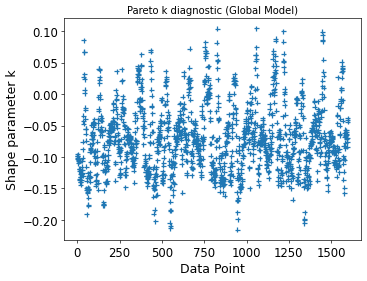

In [4]:
# Langmuir-Hinshelwood Model - 2nd step is RDS  
with pm.Model() as LH_2:
    '''
    1. CO + * -> CO* 
    2. CO* + OH* -> COOH* + * (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-)
    4. OH- + * -> OH* + (e-)
    '''
    # Priors
    deltaG1_0 = pm.Uniform('deltaG1_0', lower=-2, upper=0.1) 
    deltaG4_0 = pm.Uniform('deltaG4_0', lower=-1.5, upper=0.5) # at 0V_SHE
    Gact2_0 = pm.Uniform('Gact2_0', lower=0, upper=2) 

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0 
    log_K1 = -deltaG1/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in) 
    term_OH = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO + term_OH)
    log_theta = - pm.math.logsumexp(pt.stack([zeros, term_CO+zeros, term_OH+zeros]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pm.math.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pm.math.exp(log_theta_OH))

    # Rate expression
    log_rate = log_k2 + log_theta_CO + log_theta_OH
    alpha, delta_OH, delta_CO, log_rate = observables(log_rate)

trace_LH_2, loo_LH_2 = fit_and_evaluate(LH_2)

Kinetic Parameters found: ['deltaG1_0', 'deltaG4_0', 'Gact2_0']
Error Parameters found: ['sigma_log_rate']
                 mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0      -0.087  0.003  -0.092   -0.082      0.000    0.000    1273.0    2040.0    1.0
deltaG4_0      -0.087  0.002  -0.091   -0.083      0.000    0.000    1650.0    2306.0    1.0
Gact2_0         0.675  0.002   0.671    0.678      0.000    0.000    1452.0    2148.0    1.0
sigma_log_rate  1.516  0.033   1.456    1.578      0.001    0.001    4067.0    2596.0    1.0


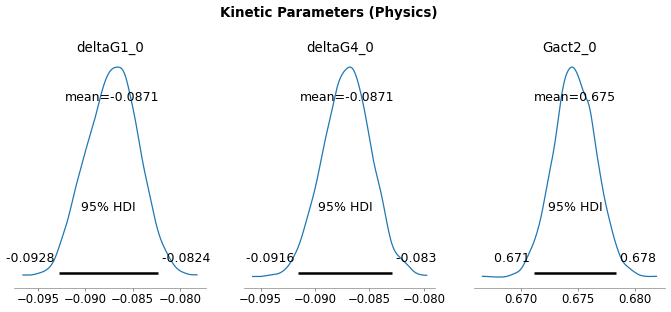

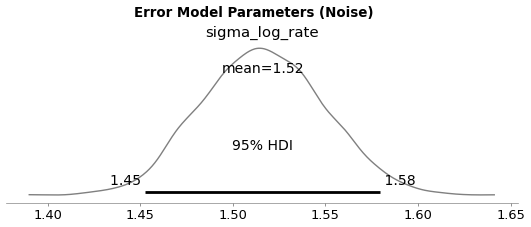

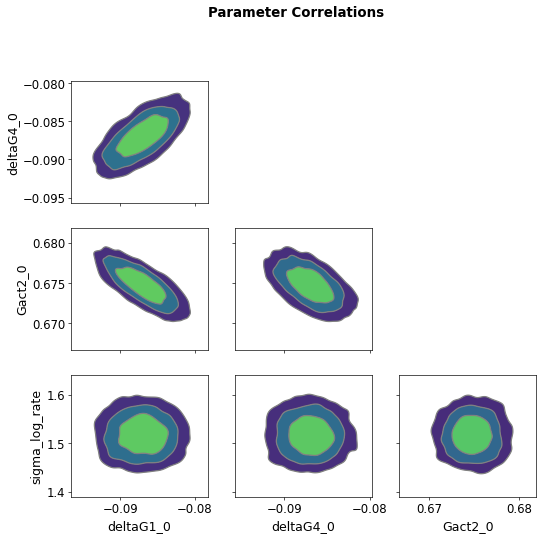

Sampling: [rate]


rate: 0.599


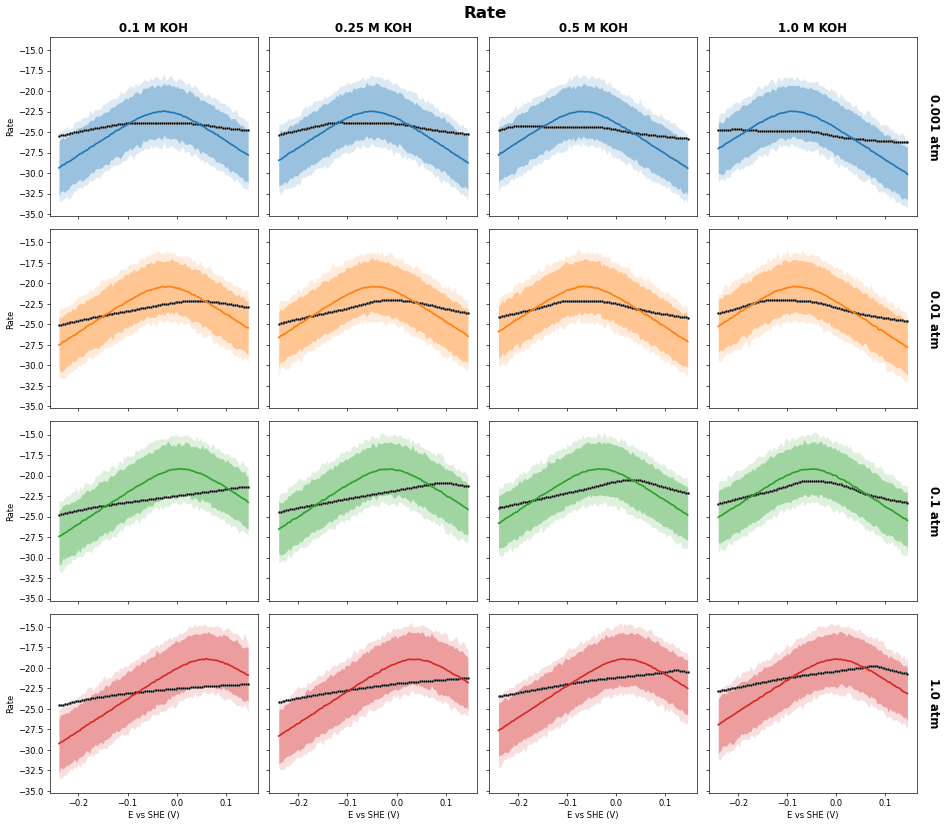

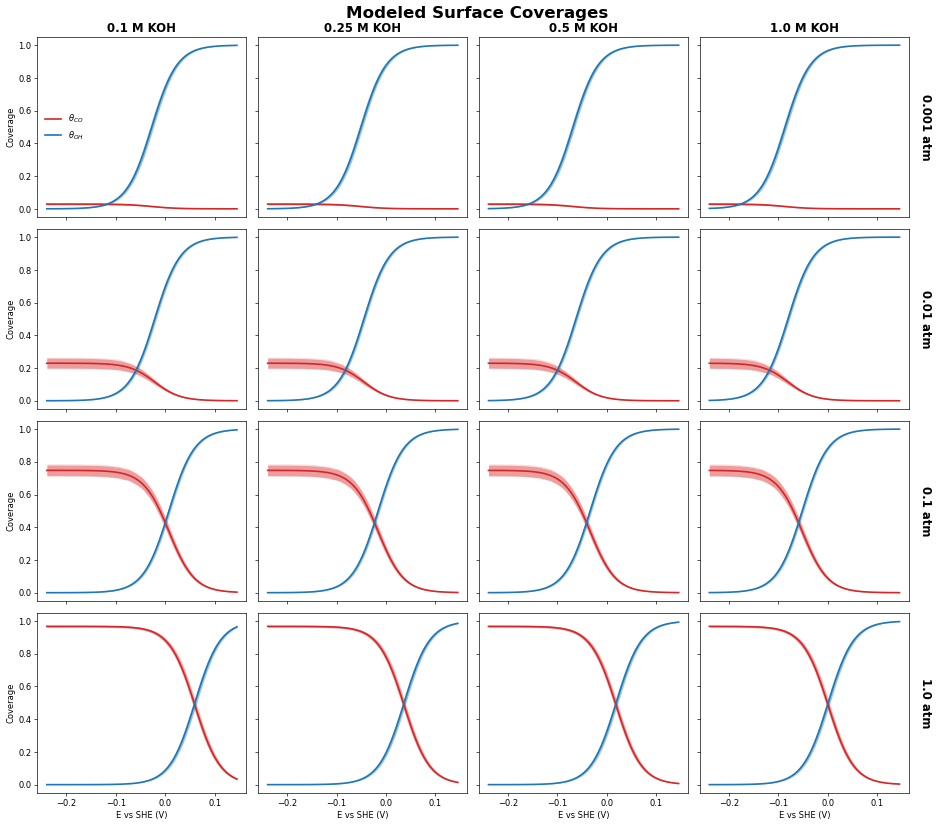

In [5]:
ppc_LH_2 = plot_posteriors(trace_LH_2, LH_2)
plot_model_fits(ppc_LH_2); plot_coverages(trace_LH_2)

# ER 2

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.37,15
,2000,0,0.39,15
,2000,0,0.34,7
,2000,0,0.35,7


Computed from 4000 posterior samples and 1600 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -1676.78    40.94
p_loo        8.04        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1600  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



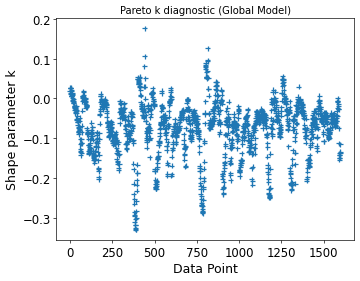

In [6]:
# Eley-Rideal Model - 2nd step is RDS  
with pm.Model() as ER_2:
    '''
    1. CO + * -> CO* 
    2. CO* + OH- -> COOH* + (e-) (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) 
    4. OH- + * -> OH* + (e-)
    '''
    # Priors
    deltaG1_0 = pm.Uniform('deltaG1_0', lower=-2, upper=0.1)
    deltaG4_0 = pm.Uniform('deltaG4_0', lower=-1.5, upper=0.5) # at 0V_SHE
    beta_2 = pm.Uniform('beta_2', lower=0.05, upper=0.95)     
    Gact2_0 = pm.Uniform('Gact2_0', lower=0, upper=2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0 - beta_2*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO + term_OH)
    log_theta = - pm.math.logsumexp(pt.stack([zeros, term_CO+zeros, term_OH+zeros]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pm.math.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pm.math.exp(log_theta_OH))

    # Rate expression
    log_rate = log_k2 + log_theta_CO + np.log(C_KOH_in)
    alpha, delta_OH, delta_CO, rate = observables(log_rate)

trace_ER_2, loo_ER_2 = fit_and_evaluate(ER_2)

Kinetic Parameters found: ['deltaG1_0', 'deltaG4_0', 'beta_2', 'Gact2_0']
Error Parameters found: ['sigma_log_rate']
                 mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0      -0.152  0.002  -0.156   -0.147        0.0      0.0    1232.0    1604.0    1.0
deltaG4_0      -0.044  0.003  -0.050   -0.037        0.0      0.0    1130.0    1635.0    1.0
beta_2          0.269  0.006   0.258    0.279        0.0      0.0    1456.0    1797.0    1.0
Gact2_0         0.745  0.001   0.744    0.747        0.0      0.0    1755.0    1694.0    1.0
sigma_log_rate  0.518  0.012   0.497    0.543        0.0      0.0    3369.0    2851.0    1.0


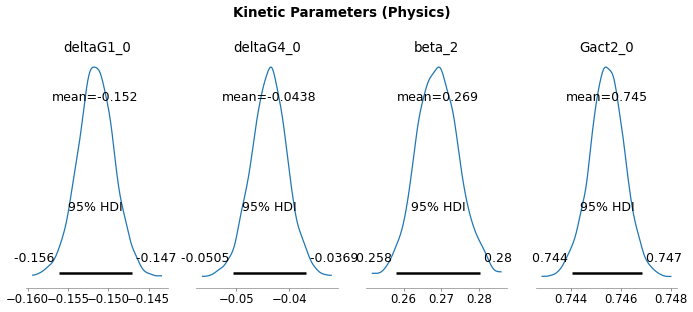

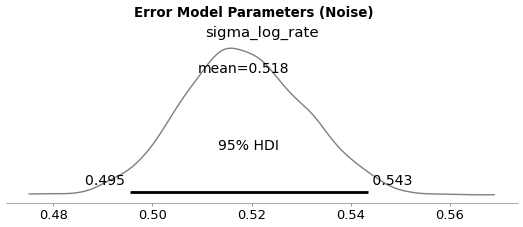

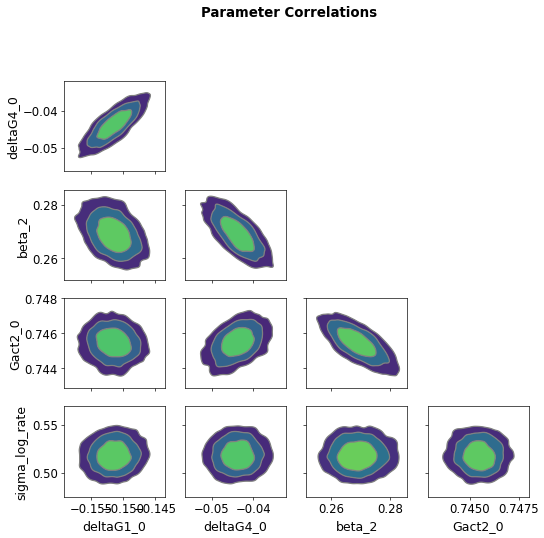

Sampling: [rate]


rate: 0.729


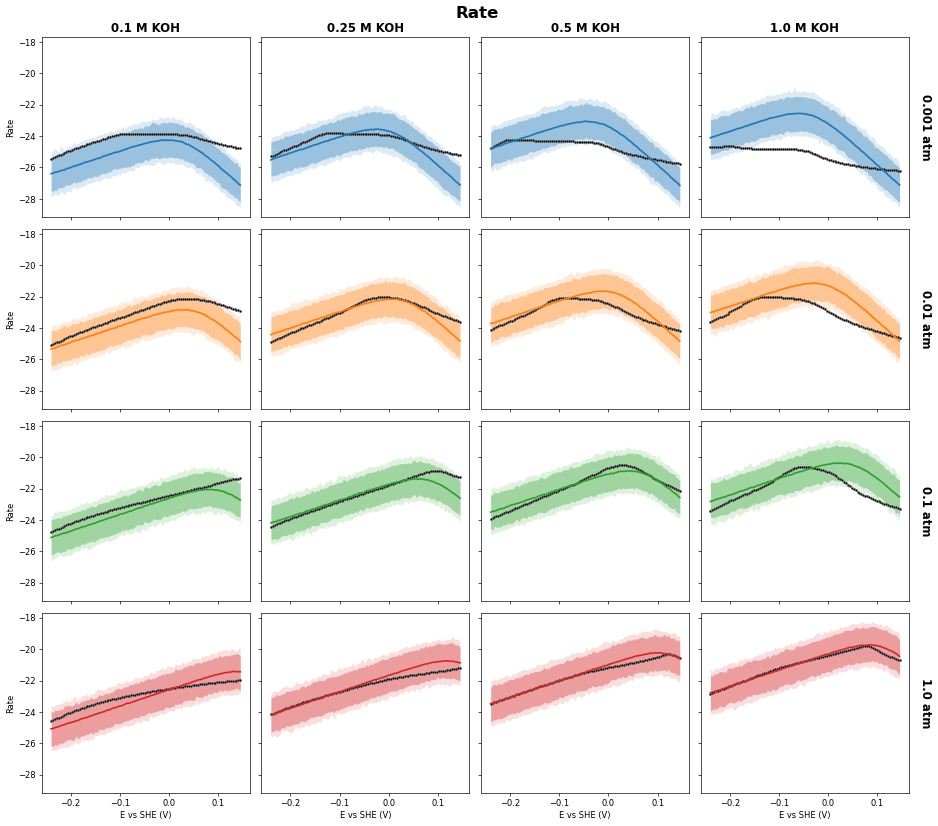

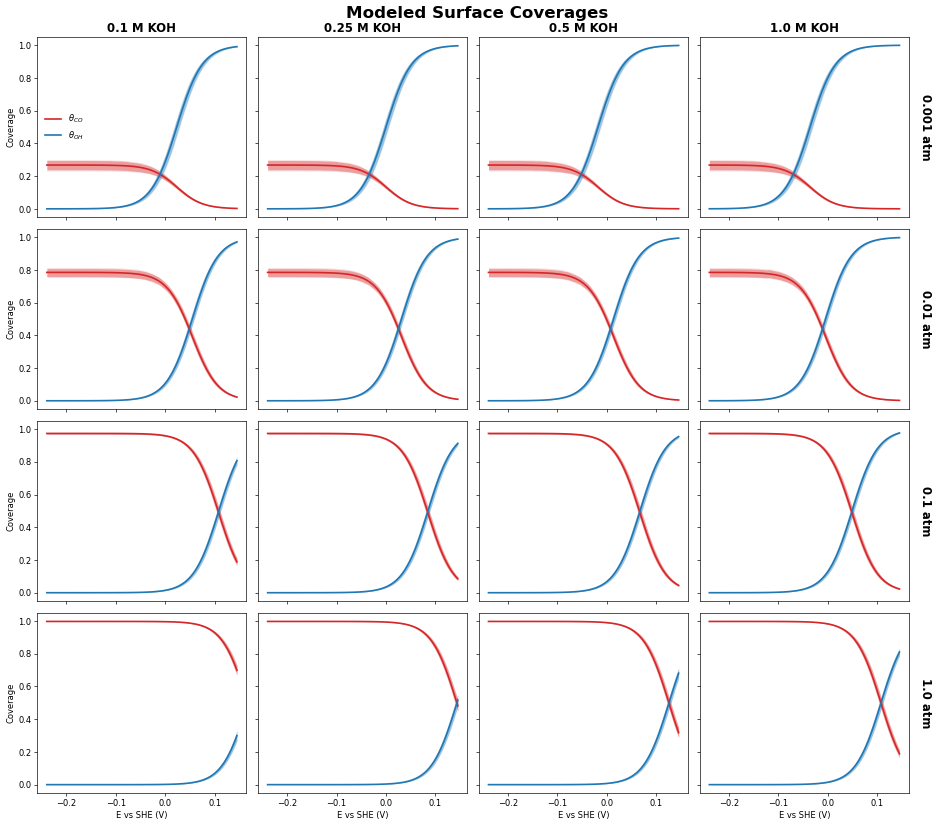

In [7]:
ppc_ER_2 = plot_posteriors(trace_ER_2, ER_2)
plot_model_fits(ppc_ER_2); plot_coverages(trace_ER_2)

# ER 3

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.03,1023
,2000,0,0.04,1023
,2000,0,0.04,127
,2000,0,0.03,95


Computed from 4000 posterior samples and 1600 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -2314.06    41.25
p_loo        7.99        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1600  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



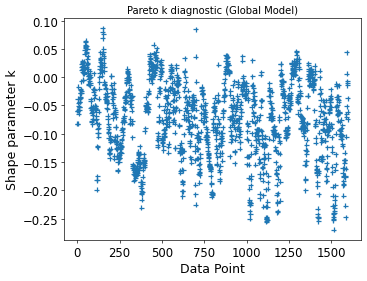

In [8]:
# Eley-Rideal Model - 3rd step is RDS  
with pm.Model() as ER_3:
    '''
    1. CO + * -> CO* 
    2. CO* + OH- -> COOH* + (e-) 
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (RDS)
    4. OH- + * -> OH* + (e-)
    '''
    # Priors
    deltaG1_0 = pm.Uniform('deltaG1_0', lower=-2, upper=0.1) 
    deltaG4_0 = pm.Uniform('deltaG4_0', lower=-1.5, upper=0.5) # at 0V_SHE
    deltaG2_0 = pm.Normal('deltaG2_0', mu=0, sigma=0.5) # at 0V_SHE
    beta_3 = pm.Uniform('beta_3', lower=0.05, upper=0.95)
    Gact3_0 = pm.Uniform('Gact3_0', lower=0, upper=2) # at 0V_SHE
    
    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG2 = deltaG2_0 - E_in
    deltaG4 = deltaG4_0 - E_in
    Gact3 = Gact3_0 - beta_3*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K2 = -deltaG2/(kb_eV*T)
    log_k3 = np.log(kb_J*T/h) - Gact3/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 + np.log(C_KOH_in)
    term_COOH = log_K2 + term_CO + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_COOH)
    log_theta = - pm.math.logsumexp(pt.stack([zeros, term_CO+zeros, term_OH+zeros, term_COOH]), axis=0) 
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta
    log_theta_COOH = term_COOH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pm.math.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pm.math.exp(log_theta_OH))

    # Rate expression
    log_rate = log_k3 + log_theta_COOH + np.log(C_KOH_in)
    alpha, delta_OH, delta_CO, rate = observables(log_rate)

trace_ER_3, loo_ER_3 = fit_and_evaluate(ER_3)

Kinetic Parameters found: ['deltaG2_0', 'deltaG1_0', 'deltaG4_0', 'beta_3', 'Gact3_0']
Error Parameters found: ['sigma_log_rate']
                 mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG2_0      -0.265  0.009  -0.283   -0.249       0.00    0.000    1642.0    1266.0   1.00
deltaG1_0      -0.733  0.329  -1.299   -0.228       0.02    0.007     283.0     537.0   1.01
deltaG4_0      -0.884  0.328  -1.464   -0.395       0.02    0.007     285.0     548.0   1.01
beta_3          0.122  0.008   0.107    0.136       0.00    0.000    2197.0    2786.0   1.00
Gact3_0         0.754  0.001   0.752    0.756       0.00    0.000    3415.0    2618.0   1.00
sigma_log_rate  0.773  0.020   0.736    0.809       0.00    0.000    4194.0    2871.0   1.00


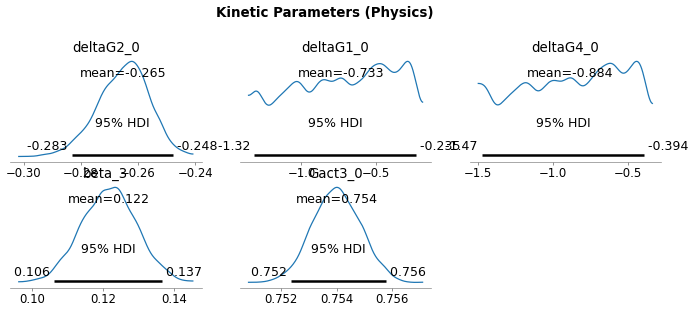

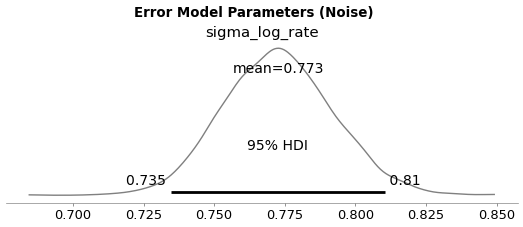

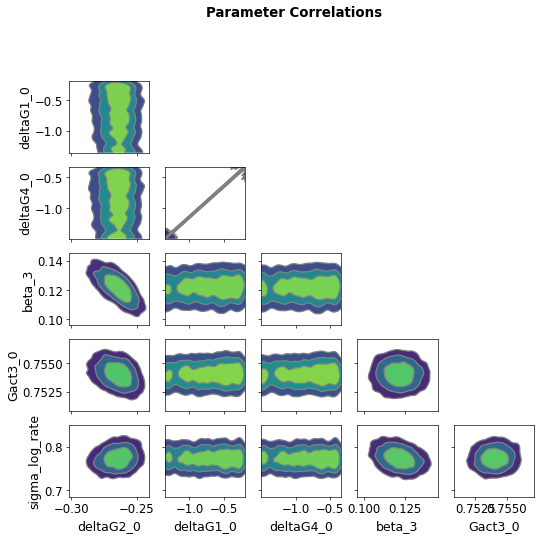

Sampling: [rate]


rate: 0.588


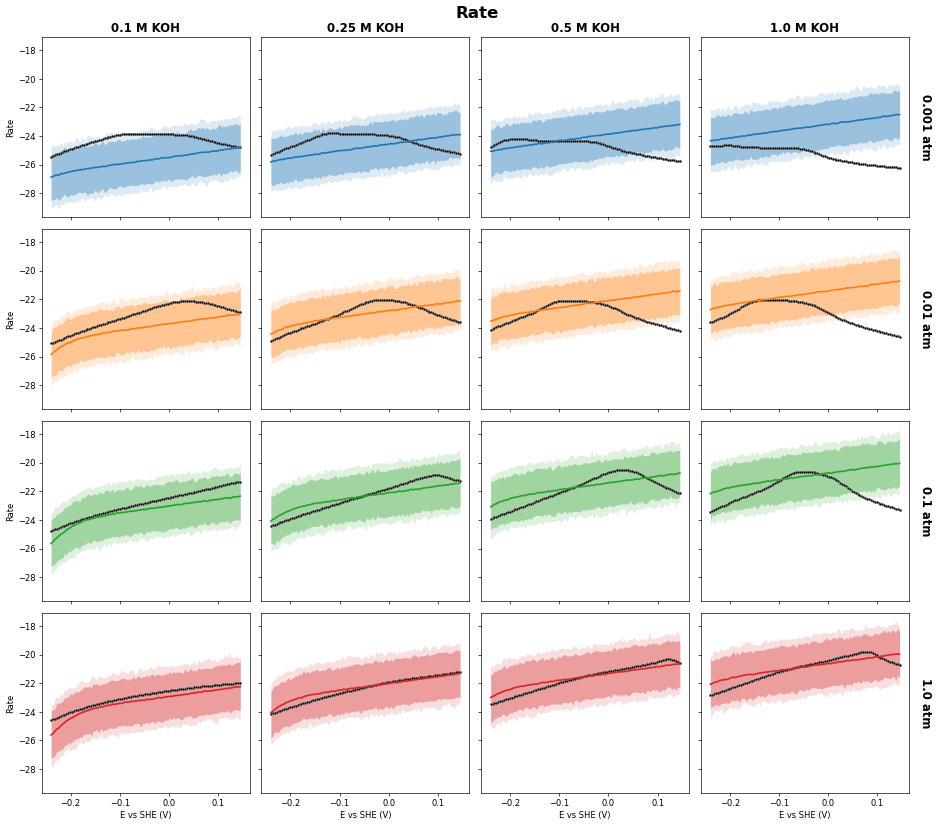

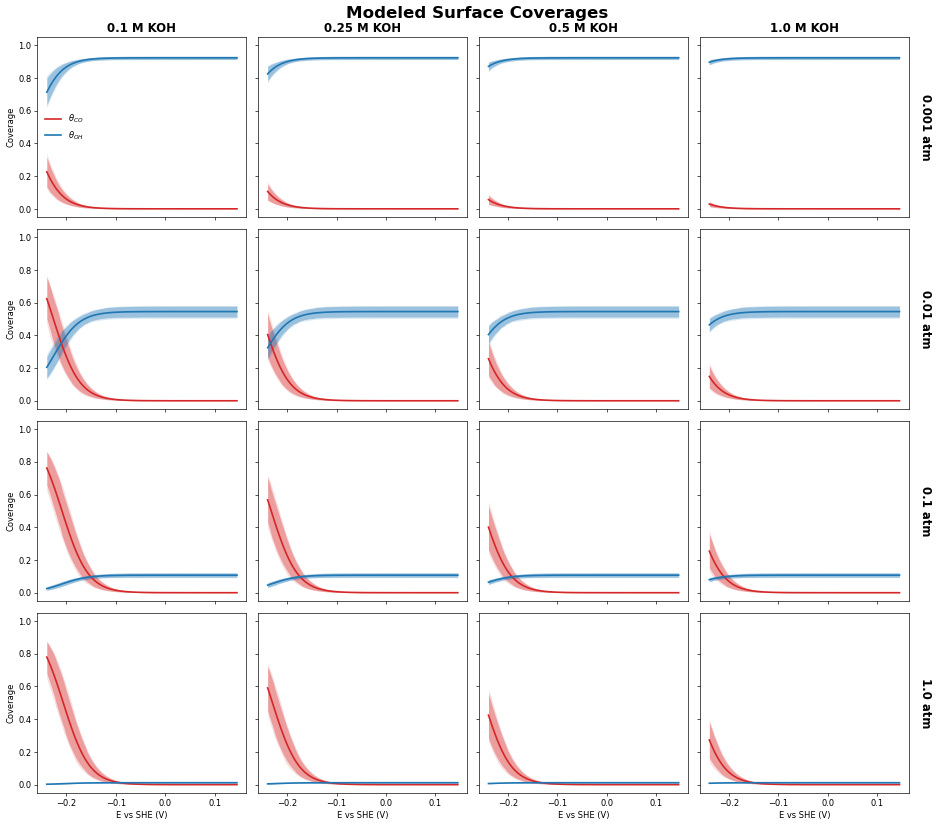

In [9]:
ppc_ER_3 = plot_posteriors(trace_ER_3, ER_3)
plot_model_fits(ppc_ER_3); plot_coverages(trace_ER_3)

# LH 3

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.05,63
,2000,0,0.04,127
,2000,0,0.05,235
,2000,0,0.04,127


Computed from 4000 posterior samples and 1600 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -2313.97    41.22
p_loo        7.87        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1600  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



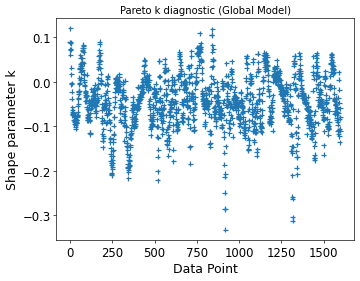

In [10]:
# Langmuir-Hinshelwood Model - 3rd step is RDS  
with pm.Model() as LH_3:
    '''
    1. CO + * -> CO* 
    2. CO* + OH* -> COOH* + * 
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (RDS)
    4. OH- + * -> OH* + (e-)
    '''
    # Priors
    deltaG1_0 = pm.Uniform('deltaG1_0', lower=-2, upper=0.1) 
    deltaG4_0 = pm.Uniform('deltaG4_0', lower=-1.5, upper=0.5) # at 0V_SHE
    deltaG2_0 = pm.Normal('deltaG2_0', mu=0, sigma=0.5) # at 0V_SHE
    beta_3 = pm.Uniform('beta_3', lower=0.05, upper=0.95)
    Gact3_0 = pm.Uniform('Gact3_0', lower=0, upper=2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG2 = deltaG2_0 
    deltaG4 = deltaG4_0 - E_in
    Gact3 = Gact3_0 - beta_3*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K2 = -deltaG2/(kb_eV*T)
    log_k3 = np.log(kb_J*T/h) - Gact3/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in) 
    term_OH = log_K4 + np.log(C_KOH_in)
    term_COOH = log_K2 + term_CO + term_OH
    zeros = pt.zeros_like(term_COOH)
    log_theta = - pm.math.logsumexp(pt.stack([zeros, term_CO+zeros, term_OH+zeros, term_COOH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta
    log_theta_COOH = term_COOH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pm.math.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pm.math.exp(log_theta_OH))

    # Rate expression
    log_rate = log_k3 + log_theta_COOH + np.log(C_KOH_in)
    alpha, delta_OH, delta_CO, rate = observables(log_rate)

trace_LH_3, loo_LH_3 = fit_and_evaluate(LH_3)

Kinetic Parameters found: ['deltaG2_0', 'deltaG1_0', 'deltaG4_0', 'beta_3', 'Gact3_0']
Error Parameters found: ['sigma_log_rate']
                 mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG2_0       0.432  0.252   0.086    0.931      0.017    0.011     253.0     299.0   1.01
deltaG1_0      -0.545  0.252  -1.045   -0.200      0.017    0.011     253.0     297.0   1.01
deltaG4_0      -0.697  0.252  -1.207   -0.360      0.017    0.011     253.0     296.0   1.01
beta_3          0.122  0.008   0.106    0.136      0.000    0.000    2737.0    2358.0   1.00
Gact3_0         0.754  0.001   0.752    0.756      0.000    0.000    2979.0    2314.0   1.00
sigma_log_rate  0.773  0.019   0.740    0.810      0.000    0.000    3160.0    2701.0   1.00


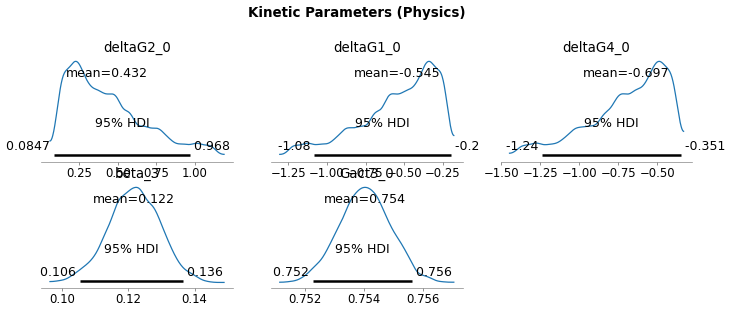

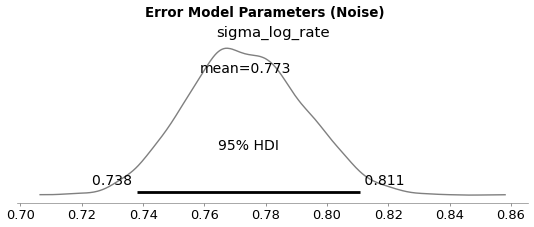

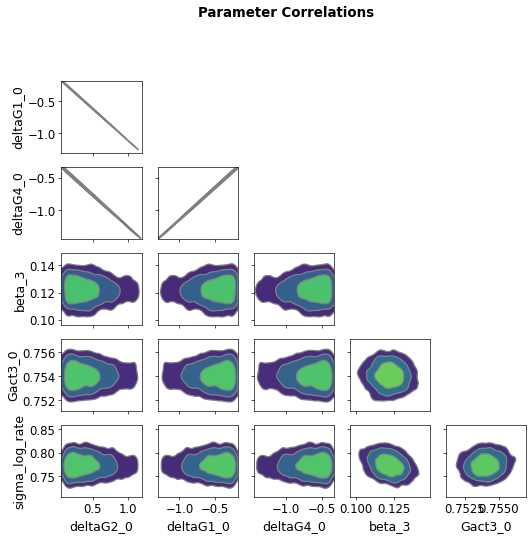

Sampling: [rate]


rate: 0.588


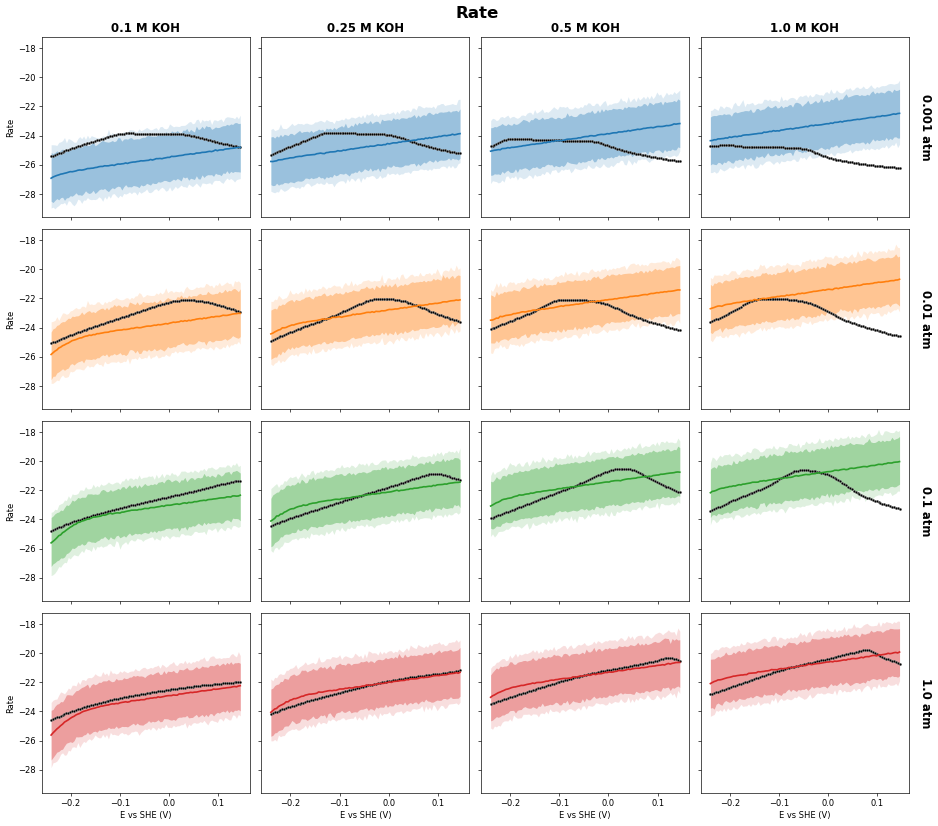

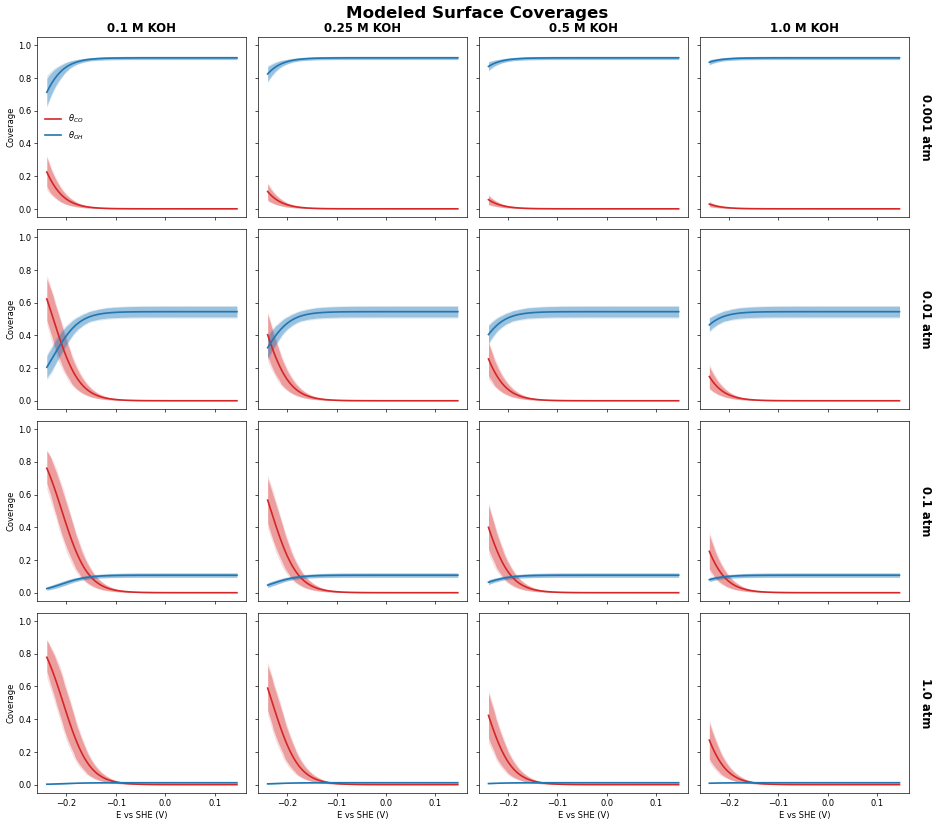

In [11]:
ppc_LH_3 = plot_posteriors(trace_LH_3, LH_3)
plot_model_fits(ppc_LH_3); plot_coverages(trace_LH_3)

# ER 2 3 - Series RDS

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.16,63
,2000,0,0.15,79
,2000,0,0.16,31
,2000,0,0.15,19


Computed from 4000 posterior samples and 1600 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -1204.63    32.86
p_loo        9.53        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1600  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



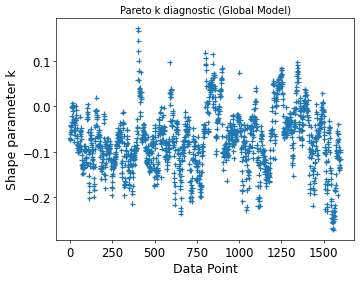

In [12]:
# Eley-Rideal Model - 2nd and 3rd steps are RDS 
with pm.Model() as ER_2_3:
    '''
    1. CO + * -> CO* 
    2. CO* + OH- -> COOH* + (e-) (RDS) (Reversible)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (RDS)
    4. OH- + * -> OH* + (e-)
    '''
    # Priors
    deltaG1_0 = pm.Uniform('deltaG1_0', lower=-2, upper=0.1) 
    deltaG4_0 = pm.Uniform('deltaG4_0', lower=-1.5, upper=0.5) # at 0V_SHE
    deltaG2_0 = pm.Normal('deltaG2_0', mu=0, sigma=0.5) # at 0V_SHE
    beta_2 = pm.Uniform('beta_2', lower=0.05, upper=0.95)
    beta_3 = pm.Uniform('beta_3', lower=0.05, upper=0.95)
    Gact2_0 = pm.Uniform('Gact2_0', lower=0, upper=2) # at 0V_SHE
    Gact3_0 = pm.Uniform('Gact3_0', lower=0, upper=2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG2 = deltaG2_0 - E_in
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0 - beta_2*E_in
    Gact3 = Gact3_0 - beta_3*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K2 = -deltaG2/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)
    log_k3 = np.log(kb_J*T/h) - Gact3/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 + np.log(C_KOH_in)
    term_COOH = log_k2 + term_CO + np.log(C_KOH_in) - pm.math.logaddexp(log_k2 - log_K2, log_k3 + np.log(C_KOH_in))
    zeros = pt.zeros_like(term_CO + term_OH)
    log_theta = - pm.math.logsumexp(pt.stack([zeros, term_CO+zeros, term_OH+zeros, term_COOH+zeros]), axis=0) 
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta
    log_theta_COOH = term_COOH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pm.math.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pm.math.exp(log_theta_OH))

    # Rate expression
    log_rate = log_k3 + log_theta_COOH + np.log(C_KOH_in)
    alpha, delta_OH, delta_CO, rate = observables(log_rate)

trace_ER_2_3, loo_ER_2_3 = fit_and_evaluate(ER_2_3)

Kinetic Parameters found: ['deltaG2_0', 'deltaG1_0', 'deltaG4_0', 'beta_2', 'beta_3', 'Gact2_0', 'Gact3_0']
Error Parameters found: ['sigma_log_rate']
                 mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG2_0      -0.684  0.234  -1.142   -0.377      0.007    0.006    1495.0    1340.0   1.01
deltaG1_0      -0.169  0.008  -0.182   -0.155      0.000    0.000     812.0     857.0   1.00
deltaG4_0      -0.239  0.008  -0.253   -0.225      0.000    0.000     811.0     744.0   1.00
beta_2          0.829  0.010   0.811    0.848      0.000    0.000    1367.0    1849.0   1.00
beta_3          0.198  0.007   0.184    0.211      0.000    0.000    2486.0    2544.0   1.00
Gact2_0         0.611  0.003   0.604    0.617      0.000    0.000    1336.0    1806.0   1.00
Gact3_0         0.745  0.001   0.744    0.746      0.000    0.000    3885.0    2850.0   1.00
sigma_log_rate  0.407  0.010   0.389    0.425      0.000    0.000    4642.0    2207.0   1.00


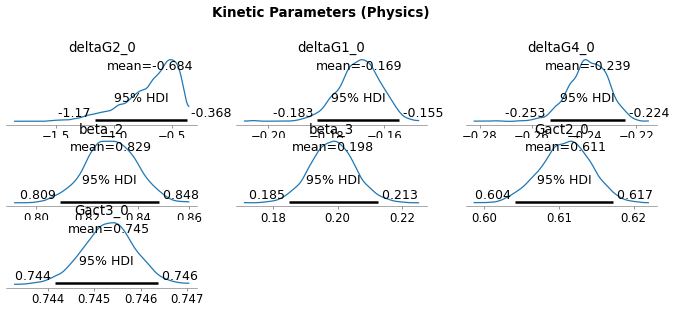

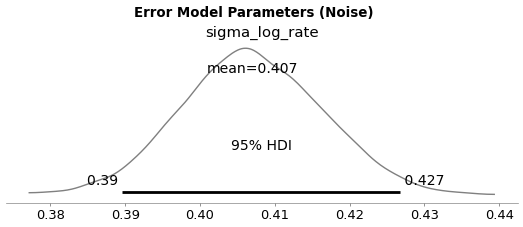

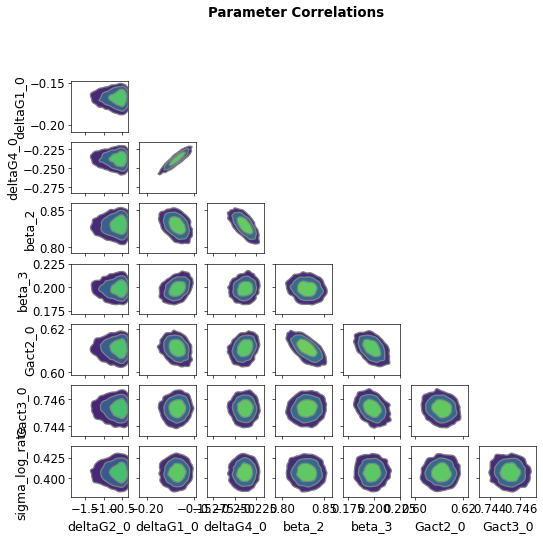

Sampling: [rate]


rate: 0.800


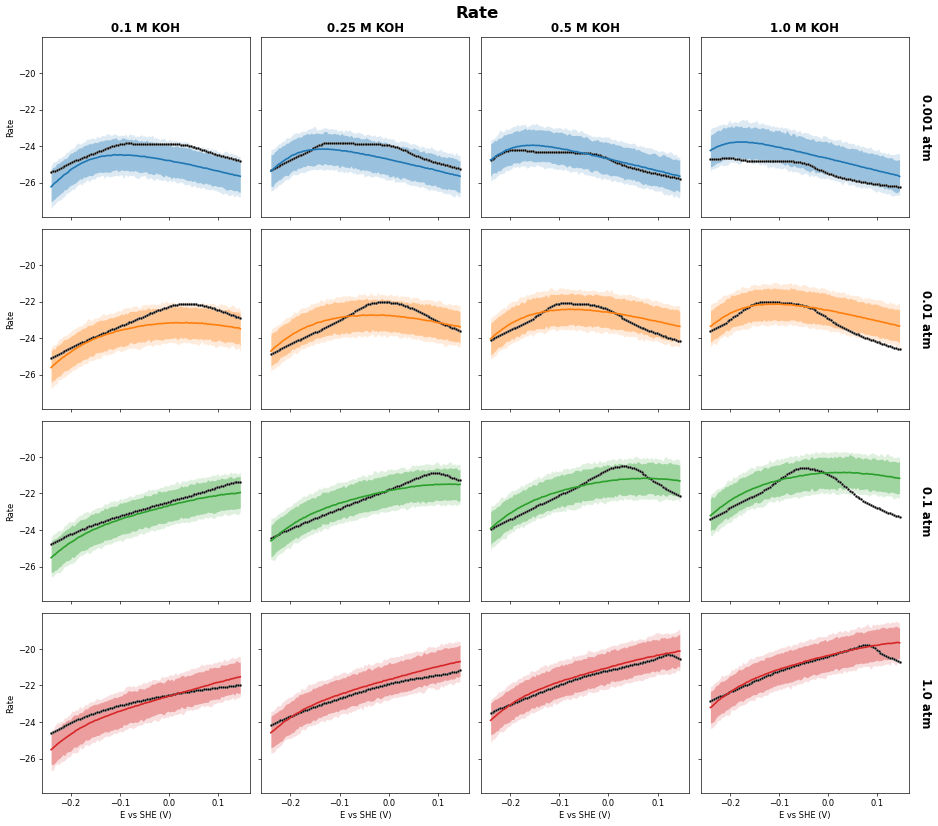

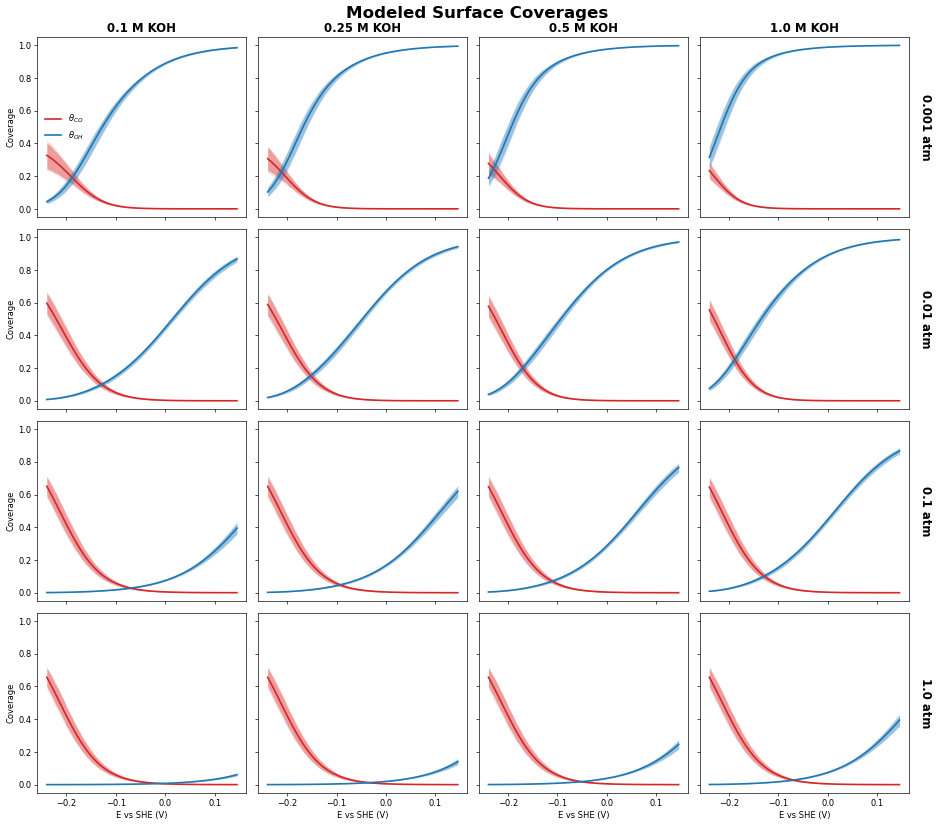

In [13]:
ppc_ER_2_3 = plot_posteriors(trace_ER_2_3, ER_2_3)
plot_model_fits(ppc_ER_2_3); plot_coverages(trace_ER_2_3)

# ER 2 + LH 2 - Parallel RDS

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.35,15
,2000,0,0.32,15
,2000,0,0.35,15
,2000,0,0.34,15


Computed from 4000 posterior samples and 1600 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -1575.28    40.99
p_loo        9.25        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1600  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



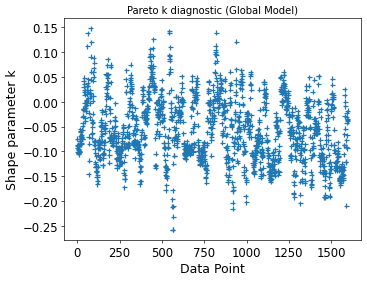

In [14]:
# Eley-Rideal + Langmuir-Hinshelwood Hybrid Model - 2nd step is RDS
with pm.Model() as ER_LH_2:
    '''
    1. CO + * -> CO* 
    2a. CO* + OH- -> COOH* + (e-) (RDS)
    2b. CO* + OH* -> COOH* + * (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) 
    4. OH- + * -> OH* + (e-)
    '''
    # Priors
    deltaG1_0 = pm.Uniform('deltaG1_0', lower=-2, upper=0.1) 
    deltaG4_0 = pm.Uniform('deltaG4_0', lower=-1.5, upper=0.5) # at 0V_SHE
    beta_2 = pm.Uniform('beta_2', lower=0.05, upper=0.95)
    Gact2_0_LH = pm.Uniform('Gact2_0_LH', lower=0, upper=2)
    Gact2_0_ER = pm.Uniform('Gact2_0_ER', lower=0, upper=2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2_LH = Gact2_0_LH
    Gact2_ER = Gact2_0_ER - beta_2*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO + term_OH)
    log_theta = - pm.math.logsumexp(pt.stack([zeros, term_CO+zeros, term_OH+zeros]), axis=0) 
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pm.math.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pm.math.exp(log_theta_OH))

    # Rate expression
    log_rate_ER = log_k2_ER + log_theta_CO + np.log(C_KOH_in)
    log_rate_LH = log_k2_LH + log_theta_CO + log_theta_OH
    log_rate = pm.math.logaddexp(log_rate_ER, log_rate_LH)
    alpha, delta_OH, delta_CO, rate = observables(log_rate)

trace_ER_LH_2, loo_ER_LH_2 = fit_and_evaluate(ER_LH_2)

Kinetic Parameters found: ['deltaG1_0', 'deltaG4_0', 'beta_2', 'Gact2_0_LH', 'Gact2_0_ER']
Error Parameters found: ['sigma_log_rate']
                 mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0      -0.137  0.002  -0.141   -0.134        0.0      0.0    1827.0    2179.0    1.0
deltaG4_0      -0.036  0.002  -0.041   -0.031        0.0      0.0    1810.0    2035.0    1.0
beta_2          0.232  0.006   0.221    0.243        0.0      0.0    1667.0    1939.0    1.0
Gact2_0_LH      0.760  0.002   0.756    0.765        0.0      0.0    2193.0    2186.0    1.0
Gact2_0_ER      0.749  0.001   0.748    0.750        0.0      0.0    1926.0    2233.0    1.0
sigma_log_rate  0.486  0.012   0.465    0.509        0.0      0.0    3461.0    3046.0    1.0


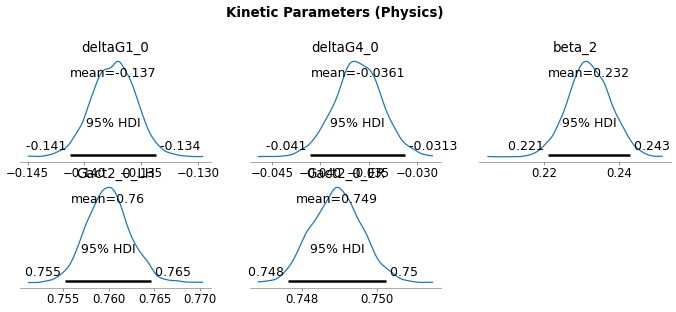

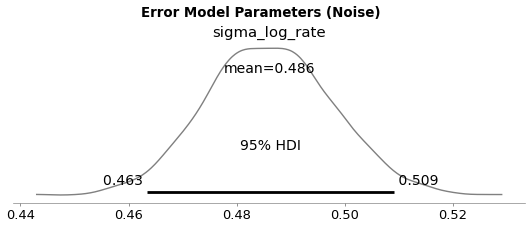

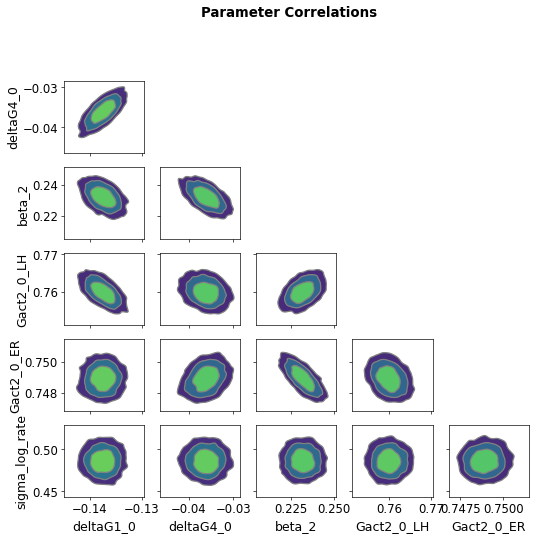

Sampling: [rate]


rate: 0.746


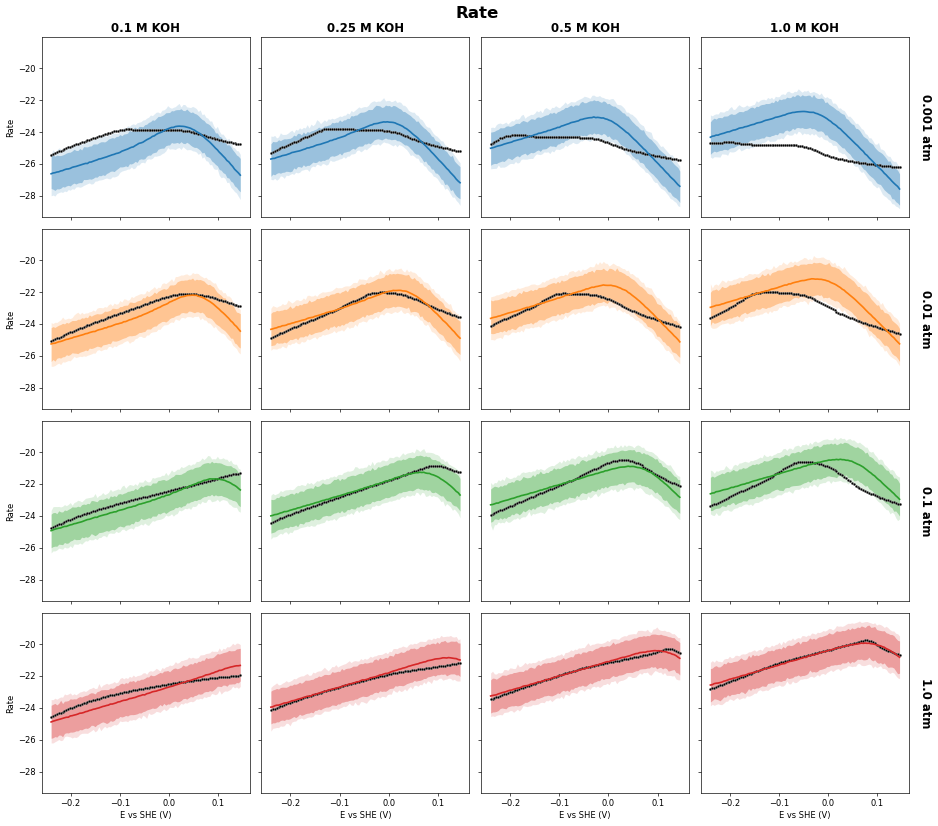

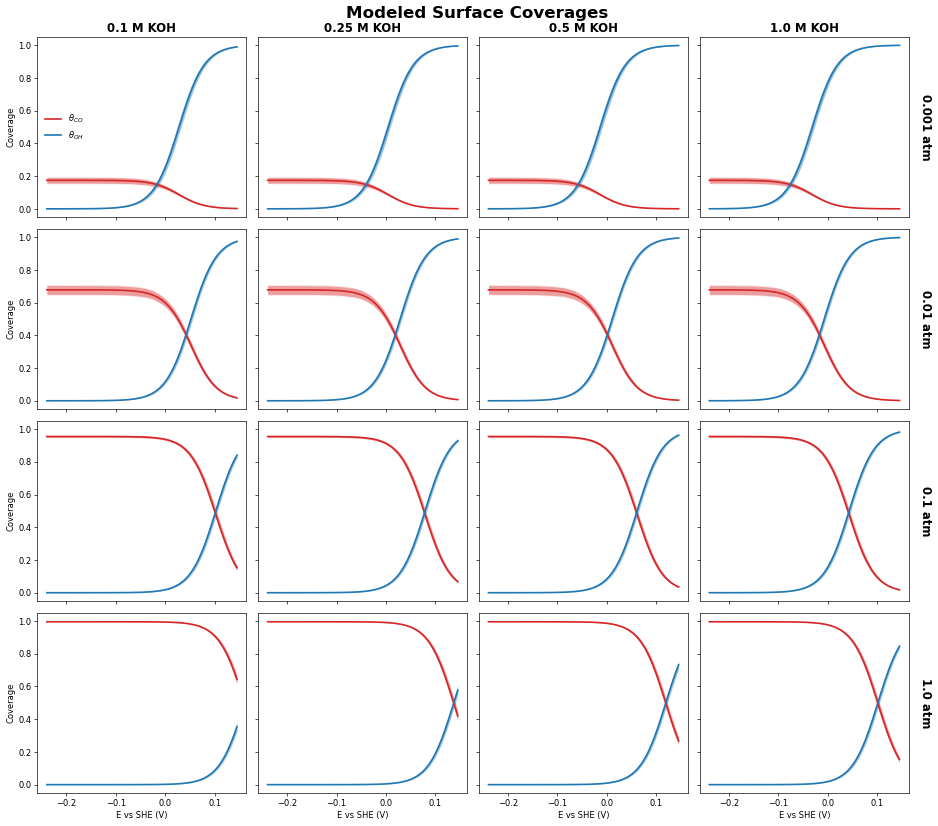

In [15]:
ppc_ER_LH_2 = plot_posteriors(trace_ER_LH_2, ER_LH_2)
plot_model_fits(ppc_ER_LH_2); plot_coverages(trace_ER_LH_2)

# ER 2 + LH 2 + 3 - Series and Parallel RDS

In [16]:
# Helper functions 

def quadratic_solve(a, b, c): 
    max_val = pt.maximum(pt.abs(a), pt.maximum(pt.abs(b), pt.abs(c)))
    a_n = a / max_val; b_n = b / max_val; c_n = c / max_val
    discriminant = pt.sqr(b_n) - 4 * a_n *c_n
    sqrt_disc = pt.sqrt(discriminant)
    root_pos = -2 * c_n / (b_n + sqrt_disc)
    root_neg = (sqrt_disc - b_n) / (2 * a_n)
    return pt.switch(pt.gt(b_n, 0), root_pos, root_neg)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.12,127
,2000,4,0.08,15
,2000,0,0.03,127
,2000,2,0.05,127


Computed from 4000 posterior samples and 1600 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -1204.81    32.84
p_loo        9.82        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1600  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



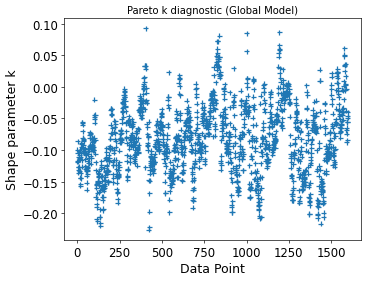

In [20]:
# Eley-Rideal + Langmuir-Hinshelwood Hybrid Model - 2nd and 3rd steps are RDS
with pm.Model() as ER_LH_2_3:
    '''
    1. CO + * -> CO* 
    2a. CO* + OH- -> COOH* + (e-) (RDS) (Reversible)
    2b. CO* + OH* -> COOH* + * (RDS) (Reversible)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (RDS)
    4. OH- + * -> OH* + (e-)
    '''
    # Priors
    deltaG1_0 = pm.Uniform('deltaG1_0', lower=-2, upper=0.1) 
    deltaG4_0 = pm.Uniform('deltaG4_0', lower=-1.5, upper=0.5) # at 0V_SHE
    deltaG2_LH_0 = pm.Normal('deltaG2_LH_0', mu=0, sigma=0.5) # at 0V_SHE
    deltaG2_ER_0 = deltaG2_LH_0 + deltaG4_0 # Hess' law
    beta_2 = pm.Uniform("beta_2", lower=0.05, upper=0.95)
    beta_3 = pm.Uniform("beta_3", lower=0.05, upper=0.95)
    Gact2_LH_0 = pm.Uniform('Gact2_LH_0', lower=0, upper=2)
    Gact2_ER_0 = pm.Uniform('Gact2_ER_0', lower=0, upper=2) # at 0V_SHE
    Gact3_0 = pm.Uniform('Gact3_0', lower=0, upper=2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG2_ER = deltaG2_ER_0 - E_in
    deltaG2_LH = deltaG2_LH_0
    deltaG4 = deltaG4_0 - E_in
    Gact2_LH = Gact2_LH_0
    Gact2_ER = Gact2_ER_0 - beta_2*E_in
    Gact3 = Gact3_0 - beta_3*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K2_LH = -deltaG2_LH/(kb_eV*T)
    log_K2_ER = -deltaG2_ER/(kb_eV*T)
    log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)
    log_k3 = np.log(kb_J*T/h) - Gact3/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)

    log_C_KOH = np.log(C_KOH_in)
    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 + log_C_KOH

    zeros = pt.zeros_like(term_CO+term_OH)
    log_Z = pt.logsumexp(pt.stack([zeros, term_CO+zeros, term_OH+zeros]), axis=0); Z_term = pt.exp(log_Z)
    log_k2a_fwd = log_k2_ER + log_C_KOH; log_k2b_fwd = log_k2_LH
    log_k2a_rev = log_k2_ER - log_K2_ER; log_k2b_rev = log_k2_LH - log_K2_LH
    log_k3_fwd  = log_k3 + log_C_KOH
    log_R_sink = pt.logaddexp(log_k2a_rev, log_k3_fwd); R_sink = pt.exp(log_R_sink)
    log_a_quad = pt.logaddexp(log_k2b_fwd + term_CO + term_OH, log_Z + log_k2b_rev); a_quad = pt.exp(log_a_quad)
    b_quad = pt.exp(log_k2a_fwd + term_CO) + pt.exp(log_Z + log_R_sink) - pt.exp(log_k2b_rev)
    c_quad = -R_sink
    theta = quadratic_solve(a_quad, b_quad, c_quad)
    num_COOH = pt.exp(log_k2a_fwd + term_CO) * theta + pt.exp(log_k2b_fwd + term_CO + term_OH) * pt.sqr(theta)
    den_COOH = R_sink + pt.exp(log_k2b_rev) * theta
    theta_COOH = num_COOH / den_COOH

    theta_CO = pm.Deterministic('theta_CO', pt.exp(term_CO) * theta)
    theta_OH = pm.Deterministic('theta_OH', pt.exp(term_OH) * theta)

    log_rate = log_k3 + pt.log(theta_COOH) + log_C_KOH
    alpha, delta_OH, delta_CO, rate = observables(log_rate)
        
trace_ER_LH_2_3, loo_ER_LH_2_3 = fit_and_evaluate(ER_LH_2_3)

Kinetic Parameters found: ['deltaG2_LH_0', 'deltaG1_0', 'deltaG4_0', 'beta_2', 'beta_3', 'Gact2_LH_0', 'Gact2_ER_0', 'Gact3_0']
Error Parameters found: ['sigma_log_rate']
                 mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG2_LH_0   -0.516  0.274  -1.003   -0.143      0.008    0.007    1325.0    1583.0   1.00
deltaG1_0      -0.168  0.008  -0.182   -0.151      0.000    0.000     293.0      69.0   1.03
deltaG4_0      -0.238  0.009  -0.255   -0.222      0.000    0.000     312.0     105.0   1.03
beta_2          0.829  0.010   0.811    0.848      0.000    0.000     884.0    1186.0   1.01
beta_3          0.198  0.007   0.184    0.211      0.000    0.000    1753.0    1869.0   1.01
Gact2_LH_0      1.429  0.353   0.879    2.000      0.016    0.007     326.0      83.0   1.02
Gact2_ER_0      0.611  0.003   0.605    0.617      0.000    0.000     988.0    1281.0   1.00
Gact3_0         0.745  0.001   0.744    0.746      0.000    0.000    2556.0    1914.0

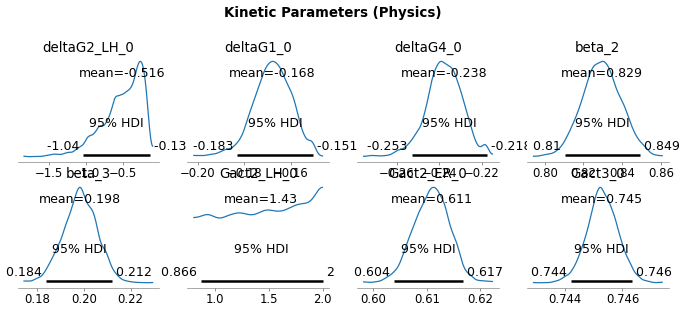

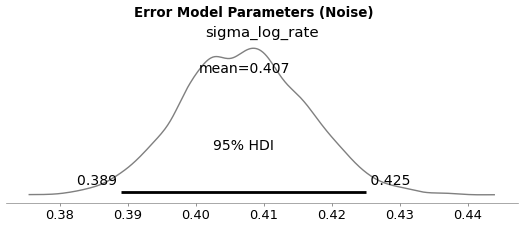

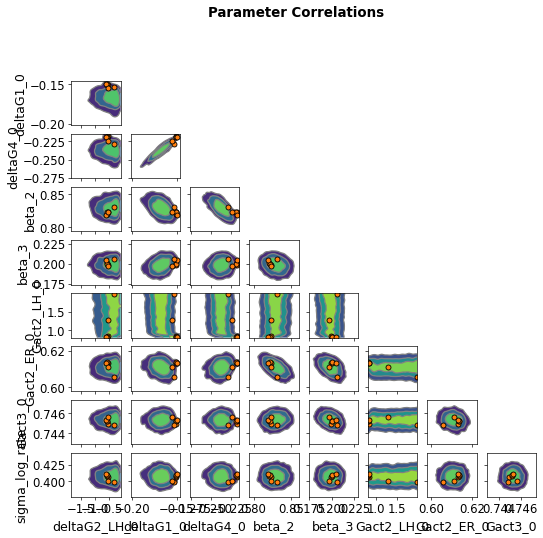

Sampling: [rate]


rate: 0.800


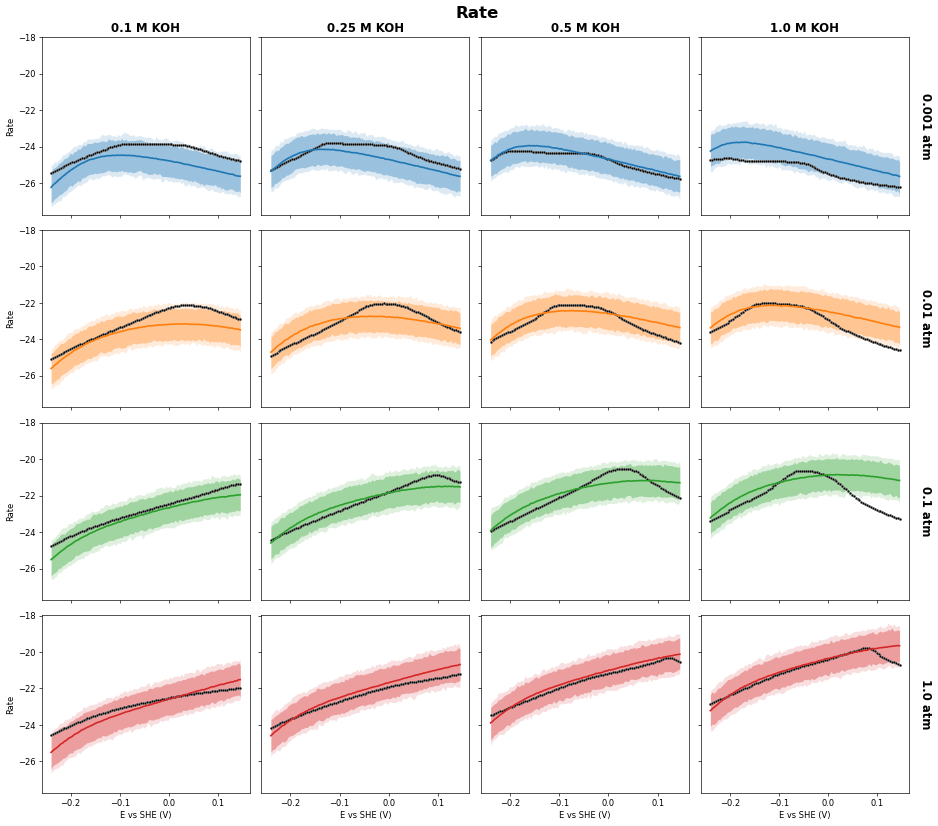

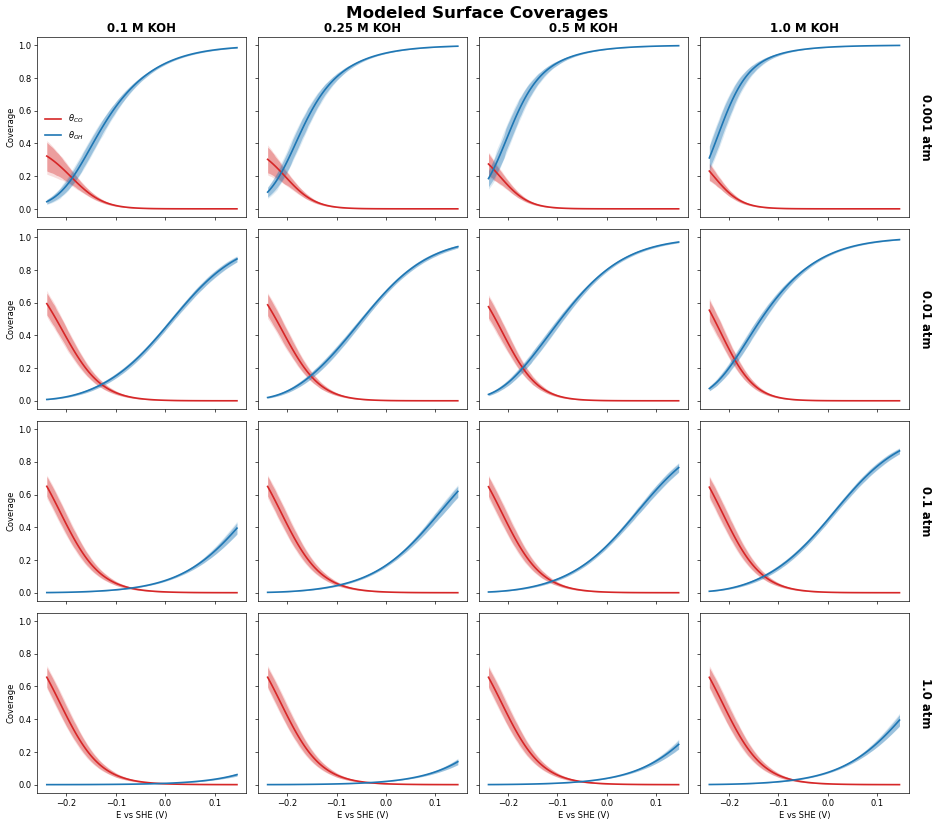

In [21]:
ppc_ER_LH_2_3 = plot_posteriors(trace_ER_LH_2_3, ER_LH_2_3)
plot_model_fits(ppc_ER_LH_2_3); plot_coverages(trace_ER_LH_2_3)

# Comparison

      rank     elpd_loo     p_loo    elpd_diff        weight         se        dse  warning scale
ER_2     0 -1676.783561  8.038142     0.000000  8.950104e-01  40.937593   0.000000    False   log
LH_3     1 -2313.974748  7.868353   637.191187  2.441531e-09  41.220938  44.783330    False   log
ER_3     2 -2314.063376  7.985190   637.279815  1.049896e-01  41.252865  44.803334    False   log
LH_2     3 -3233.818794  5.436307  1557.035233  0.000000e+00  23.781699  47.553016    False   log


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

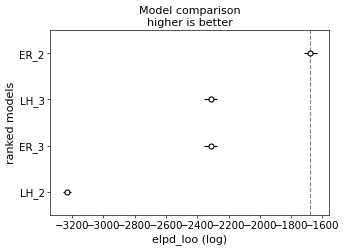

In [25]:

comparison_dict = {
    "ER_2": loo_ER_2, 
    "LH_2": loo_LH_2, 
    "ER_3": loo_ER_3, 
    "LH_3": loo_LH_3, 
    # "ER_2_3": loo_ER_2_3,  
    # "ER_LH_2": loo_ER_LH_2, 
    # "ER_LH_2_3": loo_ER_LH_2_3,

}
comp_df = az.compare(comparison_dict, ic="loo", method="stacking")
print(comp_df)
az.plot_compare(comp_df, insample_dev=False)